In [29]:
# Extract feature names after SelectKBest
selected_feature_indices = select_k_best.get_support(indices=True)
selected_feature_names = X_train_encoded.columns[selected_feature_indices]

# Verify the shape alignment between selected features and feature names
print("Number of selected features:", len(selected_feature_names))
print("Shape of X_train_selected:", X_train_selected.shape[1])

# Check if the lengths match
if len(selected_feature_names) == X_train_selected.shape[1]:
    print("Feature names are correctly aligned with the selected features.")
else:
    print("Mismatch detected: Ensure feature selection was done correctly.")

Number of selected features: 245
Shape of X_train_selected: 245
Feature names are correctly aligned with the selected features.


Lime

In [30]:
#separates a single instance from the test set
# Access the second instance (index 1) from the numpy array
row_shap_lime = X_test_scaled[1]


In [31]:
import lime
from lime import lime_tabular


feature_names = X_train_new.columns  

# Create a LimeTabularExplainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,  # Pass the numpy array directly
    feature_names=feature_names,  # Pass the original feature names from the DataFrame
    class_names=[0, 1],
    mode='classification'
)

# Explain the prediction using LIME
lime_exp = lime_explainer.explain_instance(
    data_row=row_shap_lime,
    predict_fn=rf.predict_proba
)

# Show
lime_exp.show_in_notebook(show_table=True)


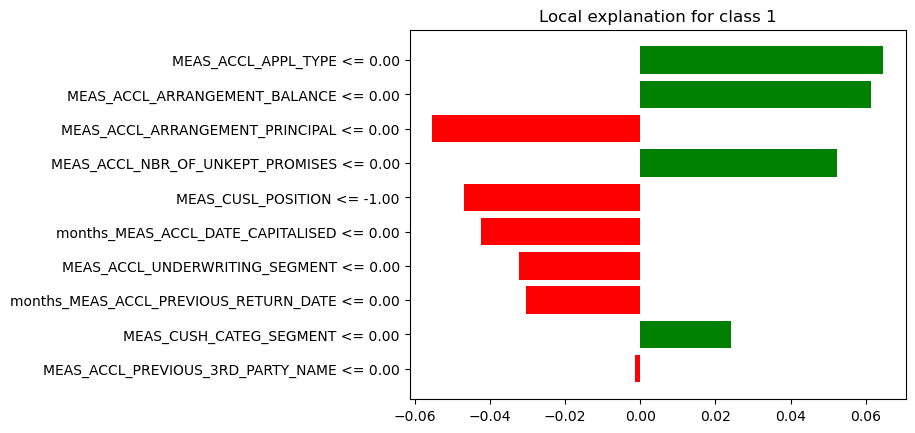

In [32]:
lime_exp.as_pyplot_figure()
print()

shap

In [33]:
#Shap Global
# Use the selected feature names when creating the SHAP explainer
shap_explainer = shap.TreeExplainer(rf)


instance = X_test_selected[1].reshape(1, -1)  
shap_values_test = shap_explainer.shap_values(instance)

# Visualize SHAP values for this instance with correct feature names
shap.initjs()
#shap.force_plot(shap_explainer.expected_value[1], shap_values_instance[1], instance, feature_names=selected_feature_names)

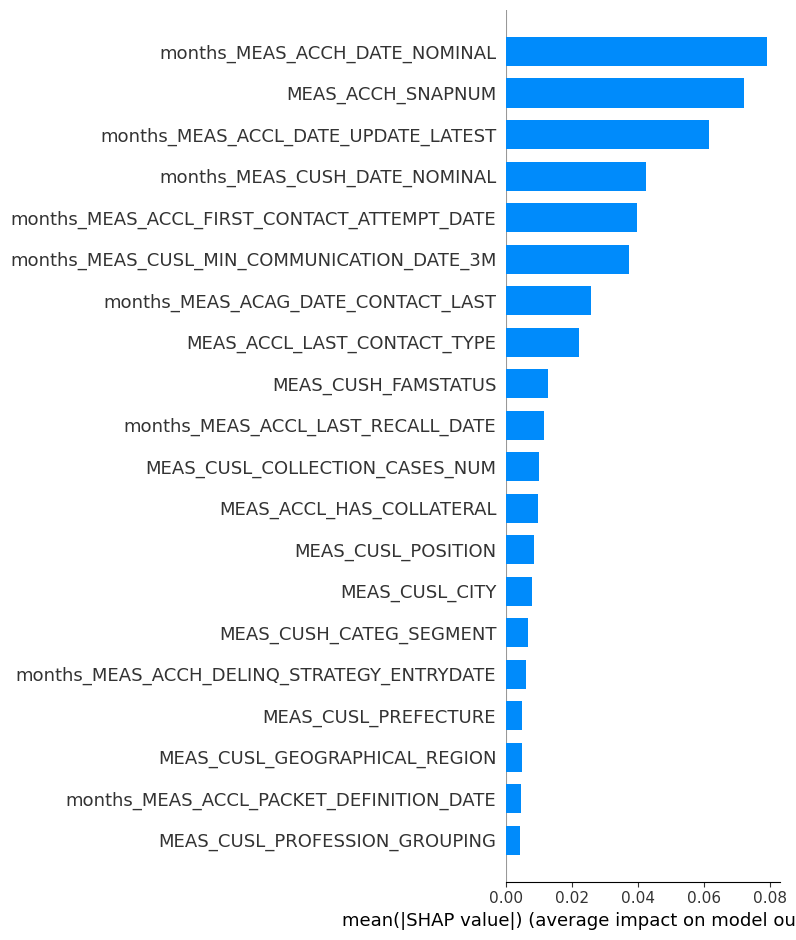

In [34]:
shap.summary_plot(shap_values_test[1], X_test_selected, feature_names=selected_feature_names, plot_type="bar")


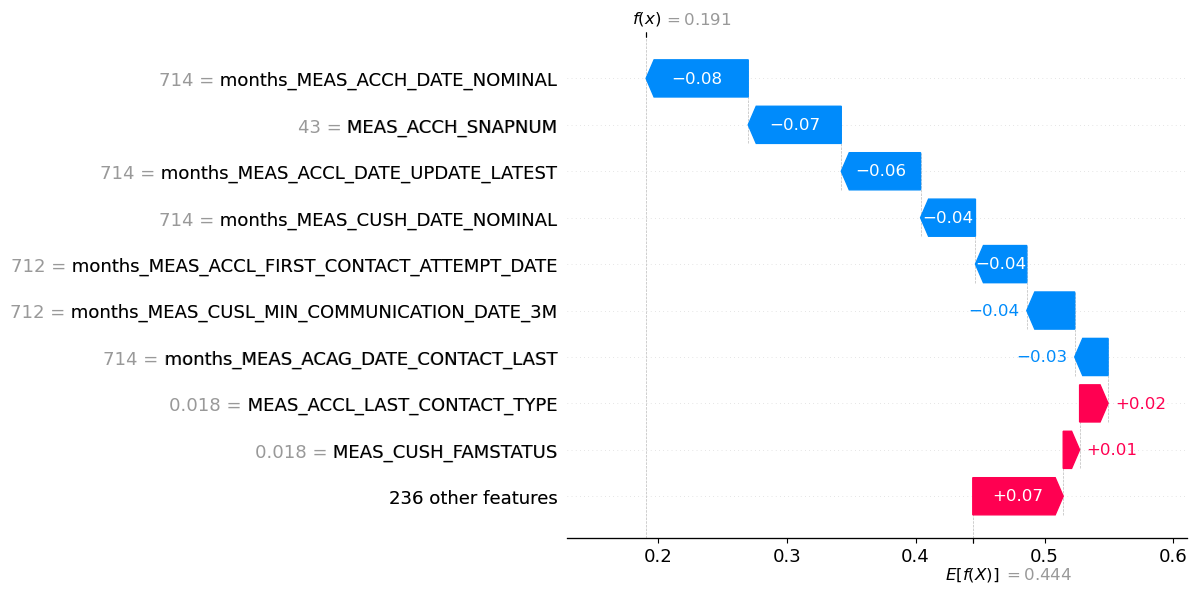

In [35]:
# Use the selected feature names when creating the SHAP explainer
shap_explainer = shap.TreeExplainer(rf)

# Choose a single instance to explain
instance = X_test_selected[1].reshape(1, -1)
shap_values_instance = shap_explainer.shap_values(instance)  # Calculating SHAP values for the instance

# Select the SHAP values for the positive class (e.g., class 1) for binary classification
# Adjust the index (e.g., shap_values_instance[0] or shap_values_instance[1]) based on your needs
shap_values_class = shap_values_instance[1]  # Assuming class 1 for binary classification

# Visualize SHAP values for this single instance with a waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_class.flatten(),  # Flatten the SHAP values to 1D
        base_values=shap_explainer.expected_value[1], 
        data=instance.flatten(),  # Ensure the data is 1-dimensional for plotting
        feature_names=selected_feature_names
    )
)
